In [44]:
import yfinance
import keras 
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [45]:
BTC   = yfinance.download('BTC-USD', period='5y', interval='1d', auto_adjust=True)['Close']

# Nidia e  AMD
NVDA  = yfinance.download('NVDA', period='5y', interval='1d', auto_adjust=True)['Close']
AMD   = yfinance.download('AMD', period='5y', interval='1d', auto_adjust=True)['Close']
SP500 = yfinance.download('^GSPC', period='5y', interval='1d'  , auto_adjust=True)['Close']
DXY   = yfinance.download('DX-Y.NYB', period='5y', interval='1d', auto_adjust=True)['Close']
TNX   = yfinance.download('^TNX', period='5y', interval='1d', auto_adjust=True)['Close']
IXIC  = yfinance.download('^IXIC', period='5y', interval='1d', auto_adjust=True)['Close']

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [46]:
df = pd.concat([BTC, NVDA, AMD, SP500, DXY, TNX, IXIC], axis=1)

> O US Dollar Index (USDX) é um índice que mede o valor do dólar americano em relação a uma cesta de seis moedas estrangeiras. Ele é calculado pela Intercontinental Exchange (ICE) e é amplamente utilizado como um indicador do valor do dólar americano no mercado de câmbio.

> O CBOE Interest Rate 10 Year T-Note (^TNX) é um índice que mede a taxa de juros dos títulos do Tesouro dos EUA com vencimento em 10 anos.

Usando arima e TLSM e variantes de RNN

In [47]:
import warnings
warnings.filterwarnings("ignore")

In [48]:
data = df.dropna()

In [49]:
data.columns = ['BTC', 'NVDA', 'AMD', 'SP500', 'DXY', 'TNX', 'IXIC']

In [50]:
Y = data['BTC'].apply(lambda x: np.log(x) ).diff(5).shift(-5)

In [51]:
Y.name = 'Target'

In [52]:
X = data.drop('BTC', axis=1)

In [53]:
X = X.apply(lambda x: np.log(x) ).diff(5)

In [54]:
dataset = pd.concat([X, Y], axis=1).dropna()
dataset.tail()

,NVDA,AMD,SP500,DXY,TNX,IXIC,Target
Date,,,,,,,
2025-08-11,0.011379,-0.025785,0.006850,-0.002636,0.017232,0.015638,-0.021101
2025-08-12,0.027117,0.003665,0.023001,-0.006908,0.022854,0.035937,-0.063039
2025-08-13,0.012022,0.122730,0.018971,-0.003469,0.004256,0.025360,-0.076372
2025-08-14,0.006891,0.048403,0.020072,-0.001526,0.011480,0.021791,-0.051494
2025-08-15,-0.012392,0.027124,0.009401,-0.003367,0.009985,0.008031,-0.004476


In [87]:
dataset.shape

(1245, 7)

> .iloc[::5, :] downsampling

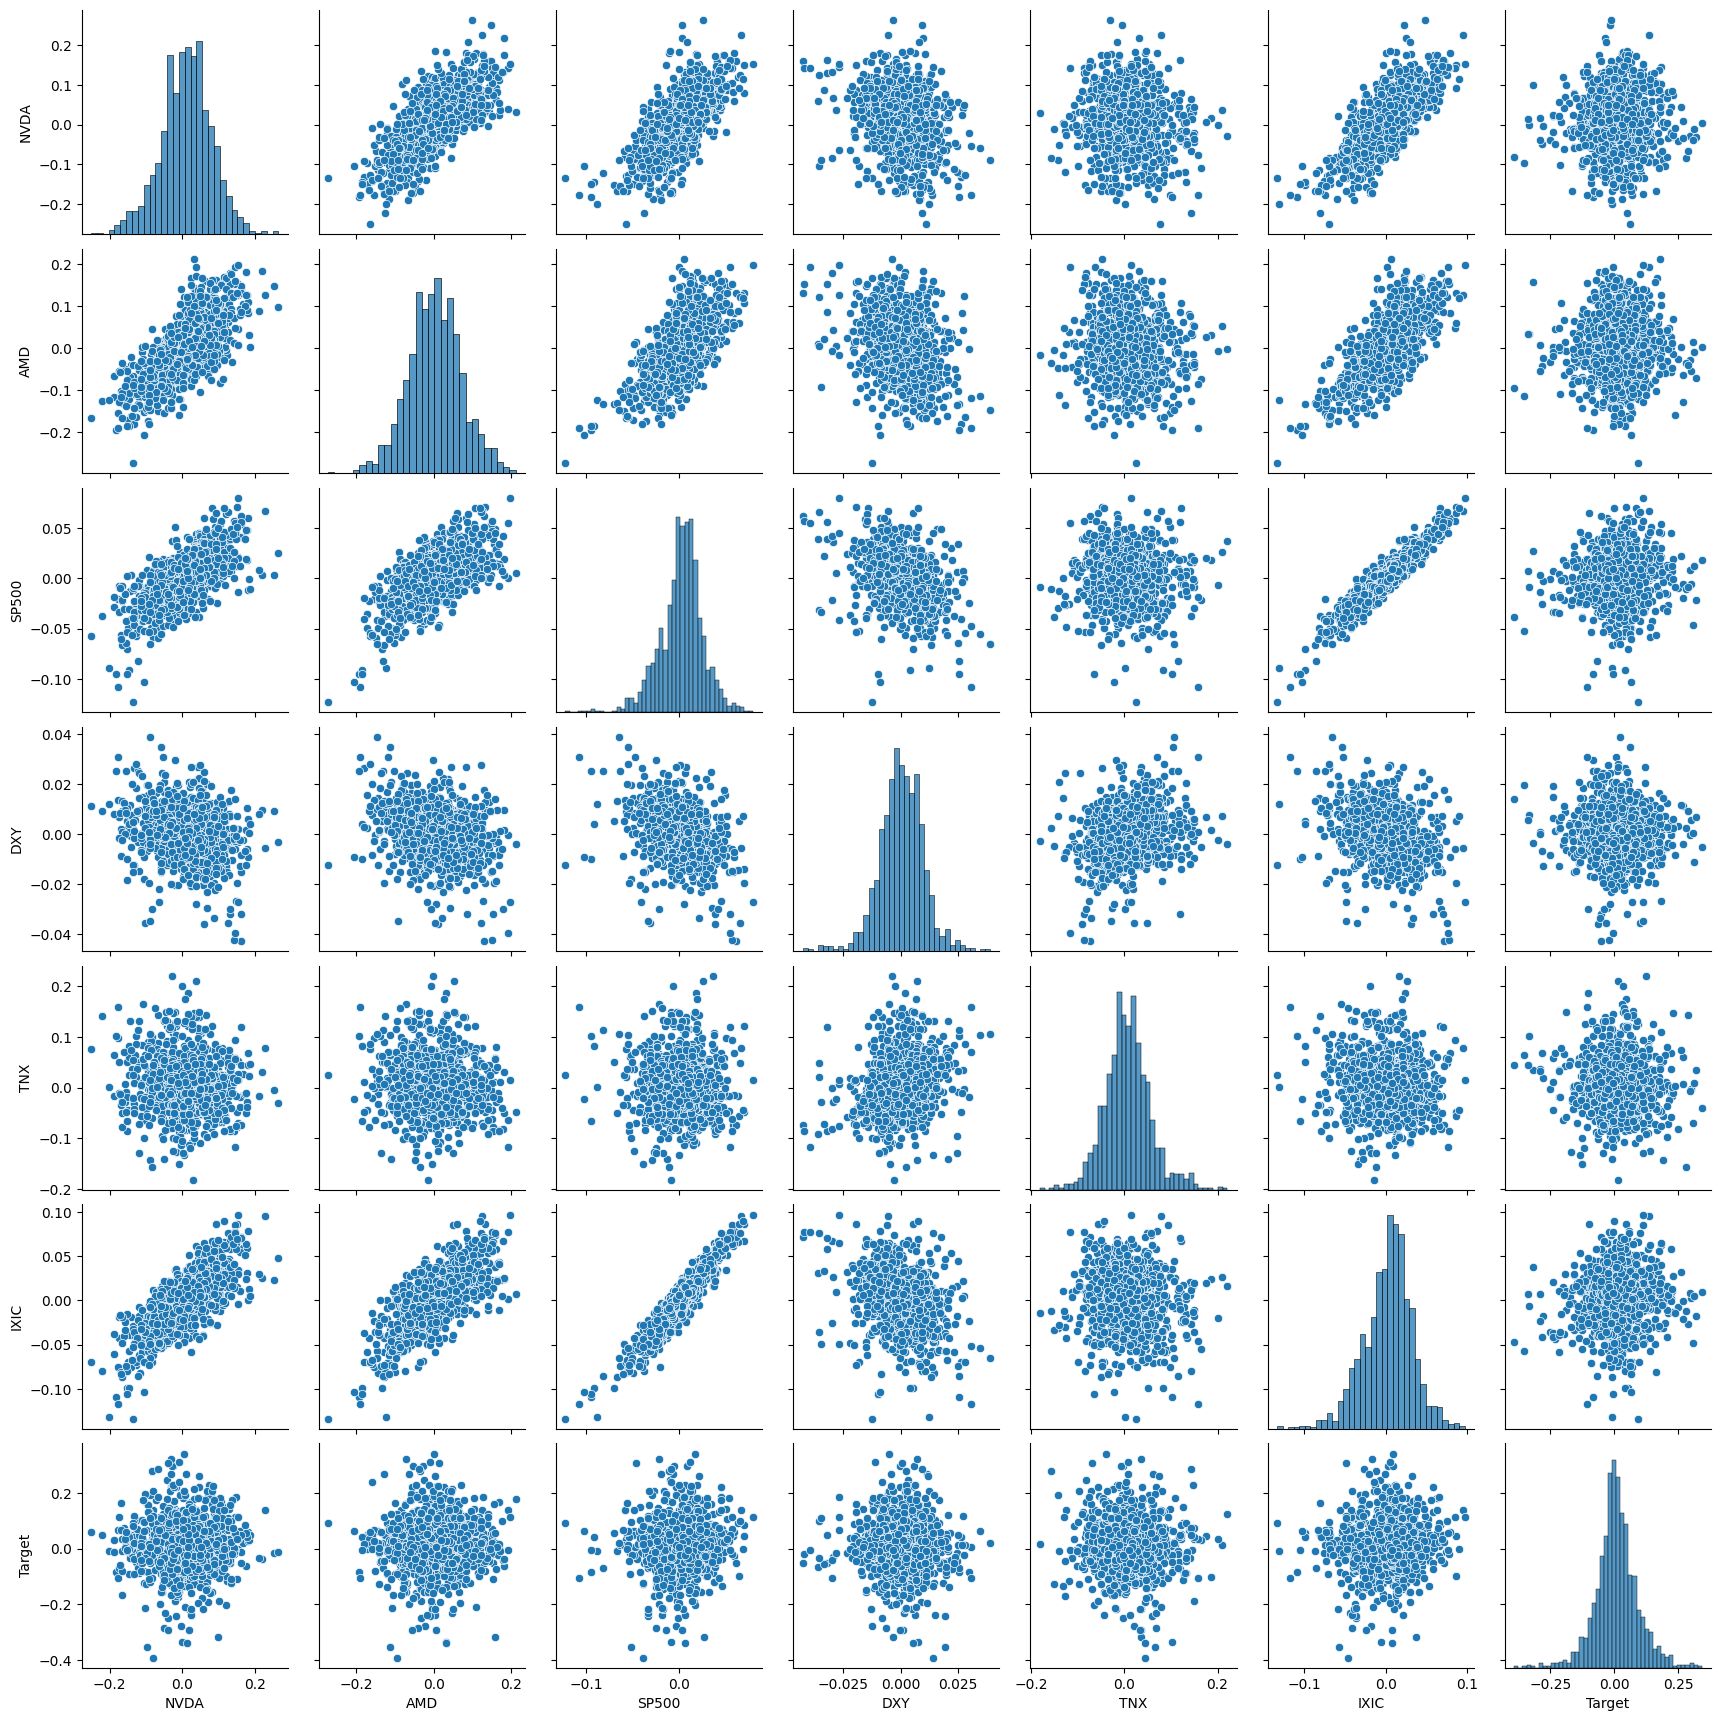

In [55]:
import seaborn as sns

sns.pairplot(dataset)
plt.show()

O uso de iloc[::return_period] não é obrigatório — ele está ali porque o autor quer criar janelas independentes, ao invés de usar todos os dados com overlap. Isso é comum em séries temporais financeiras, já que yields de um dia pro outro são muito correlacionados.

👉 Se quiser, você pode:

manter o iloc (segue o livro fielmente);

* ou remover e treinar com todos os pontos, mas vai ter mais autocorrelação nos dados;

* ou usar uma estratégia diferente, como resample por tempo (.resample('W').last()) se o índice for temporal.

In [56]:
y = dataset['Target']
X = dataset.drop('Target', axis=1)

In [57]:
X.shape

(1245, 6)

In [58]:
train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [59]:
import statsmodels.api as sm

In [60]:
arima = sm.tsa.ARIMA(y_train, exog=X_train, order=(1,0,0))

In [61]:
arima_fit = arima.fit()

In [62]:
mean_squared_error(y_test, arima_fit.predict(start=len(y_train), end=len(y_train)+len(y_test)-1, exog=X_test))

0.004094410197537629

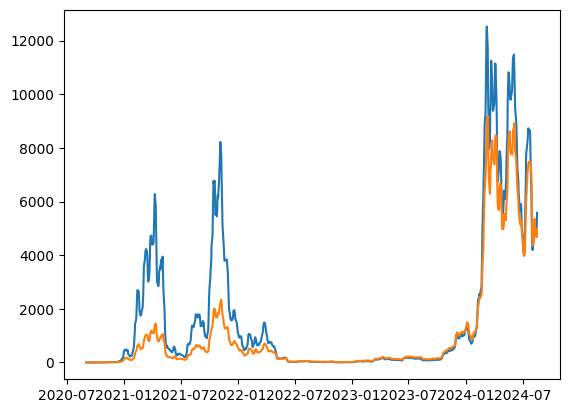

In [63]:
plt.plot(np.exp(y_train).cumprod(), label='Real')
plt.plot(np.exp(arima_fit.fittedvalues).cumprod(), label='Treino')

In [64]:
pred = arima_fit.predict(start=len(y_train), end=len(y_train)+len(y_test)-1, exog=X_test)
pred.index = y_test.index

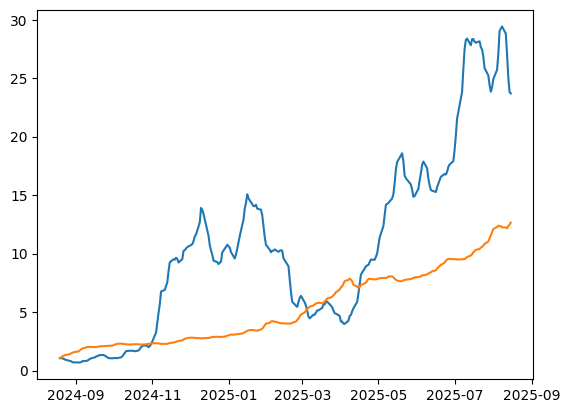

In [65]:
plt.plot(np.exp(y_test).cumprod(), label='Real Teste')
plt.plot(np.exp(pred).cumprod(), label='Teste Predito')

In [66]:
def evaluate_arima(order):
    arima = sm.tsa.ARIMA(endog=y_train, exog=X_train, order=order)
    arima_fit = arima.fit()
    
    return mean_squared_error(y_train, arima_fit.fittedvalues) 
import warnings
warnings.filterwarnings('ignore')
def evaluate_models(max_p, max_d, max_q):
    best_score, best_cfg = float("inf"), None
    for p in range(max_p+1):
        for d in range(max_d+1):
            for q in range(max_q+1):
                order = (p,d,q)
                try:
                    mse = evaluate_arima(order)
                    if mse < best_score:
                        best_score, best_cfg = mse, order
                    print(f'ARIMA{order} MSE={mse:.4f}')
                except:
                    continue
    print(f'Best ARIMA{best_cfg} MSE={best_score:.4f}')
    return best_cfg

In [67]:
evaluate_models(5,0,5)

ARIMA(0, 0, 0) MSE=0.0081
ARIMA(0, 0, 1) MSE=0.0044
ARIMA(0, 0, 2) MSE=0.0033
ARIMA(0, 0, 3) MSE=0.0031
ARIMA(0, 0, 4) MSE=0.0017
ARIMA(0, 0, 5) MSE=0.0017
ARIMA(1, 0, 0) MSE=0.0029
ARIMA(1, 0, 1) MSE=0.0029
ARIMA(1, 0, 2) MSE=0.0029
ARIMA(1, 0, 3) MSE=0.0024
ARIMA(1, 0, 4) MSE=0.0017
ARIMA(1, 0, 5) MSE=0.0017
ARIMA(2, 0, 0) MSE=0.0029
ARIMA(2, 0, 1) MSE=0.0028
ARIMA(2, 0, 2) MSE=0.0028
ARIMA(2, 0, 3) MSE=0.0023
ARIMA(2, 0, 4) MSE=0.0017
ARIMA(2, 0, 5) MSE=0.0017
ARIMA(3, 0, 0) MSE=0.0029
ARIMA(3, 0, 1) MSE=0.0029
ARIMA(3, 0, 2) MSE=0.0028
ARIMA(3, 0, 3) MSE=0.0022
ARIMA(3, 0, 4) MSE=0.0017
ARIMA(3, 0, 5) MSE=0.0017
ARIMA(4, 0, 0) MSE=0.0028
ARIMA(4, 0, 1) MSE=0.0028
ARIMA(4, 0, 2) MSE=0.0023
ARIMA(4, 0, 3) MSE=0.0022
ARIMA(4, 0, 4) MSE=0.0017
ARIMA(4, 0, 5) MSE=0.0017
ARIMA(5, 0, 0) MSE=0.0027
ARIMA(5, 0, 1) MSE=0.0026
ARIMA(5, 0, 2) MSE=0.0024
ARIMA(5, 0, 3) MSE=0.0023
ARIMA(5, 0, 4) MSE=0.0017
ARIMA(5, 0, 5) MSE=0.0017
Best ARIMA(0, 0, 4) MSE=0.0017


(0, 0, 4)

In [68]:
arima = sm.tsa.ARIMA(endog=y_train, exog=X_train, order=(0,0,5))
arima_fit = arima.fit()

In [69]:
pred = arima_fit.predict(start=len(y_train), end=len(y_train)+len(y_test)-1, exog=X_test)
pred.index = y_test.index

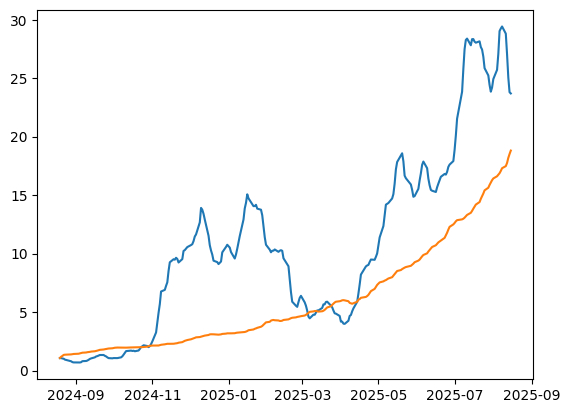

In [70]:
plt.plot(np.exp(y_test).cumprod(), label='Real')
plt.plot(np.exp(pred).cumprod(), label='Predito')

LTSM

In [71]:
def prepare_data(X_, y_, n_steps):
    X_s, y_s = [], []
    
    y_ = y_.reshape(-1,1)
    for i in range(len(X_) - n_steps):
        X_s.append(X_[i:i+n_steps])
        y_s.append(y_[i+n_steps])
    return np.array(X_s), np.array(y_s)

In [72]:
X_, Y_ = prepare_data(X.values, y.values, n_steps=5)

In [73]:
Y_.shape

(1240, 1)

In [74]:
xtrain, xtest = X_[:train_size-5], X_[train_size-5:]
ytrain, ytest = Y_[:train_size-5], Y_[train_size-5:]

In [75]:
model = keras.Sequential([
    keras.layers.LSTM(50, return_sequences=True, input_shape=(xtrain.shape[1], xtrain.shape[2])),
    keras.layers.LSTM(50),
    keras.layers.Dense(1)
])

In [76]:
model.compile(optimizer='adam', loss='mse')

In [77]:
model.fit(xtrain, ytrain, epochs=50, validation_data=(xtest, ytest), verbose=0)

In [78]:
pred = model.predict(xtest)

1/8 ━━━━━━━━━━━━━━━━━━━━ 4s 650ms/stepWARNING:tensorflow:5 out of the last 18 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x000001C4CF844AE0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step


In [79]:
mean_squared_error(ytest, pred)

0.004067360379295153

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


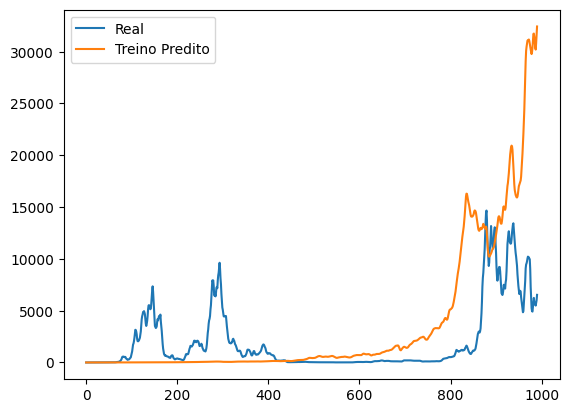

In [80]:
plt.plot(np.exp(ytrain).cumprod(), label='Real')
plt.plot(np.exp(model.predict(xtrain)).cumprod(), label='Treino Predito')
plt.legend()
plt.show()

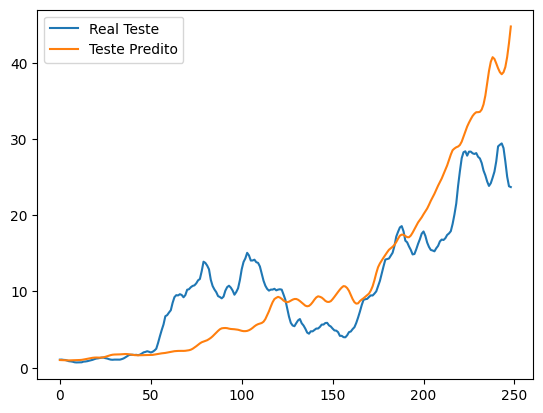

In [81]:
plt.plot(np.exp(ytest).cumprod(), label='Real Teste')
plt.plot(np.exp(pred).cumprod(), label='Teste Predito')
plt.legend()
plt.show()

Wave net

In [82]:
xtrain.shape

(991, 5, 6)

In [83]:
model = keras.Sequential([
    keras.layers.Conv1D(64, kernel_size=2, activation='relu', input_shape=(xtrain.shape[1], xtrain.shape[2])),
    keras.layers.LSTM(50),
    keras.layers.Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(xtrain, ytrain, epochs=50, validation_data=(xtest, ytest), verbose=0)

In [84]:
pred = model.predict(xtest)


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step


In [85]:
mean_squared_error(ytest, pred)

0.00705274404732836

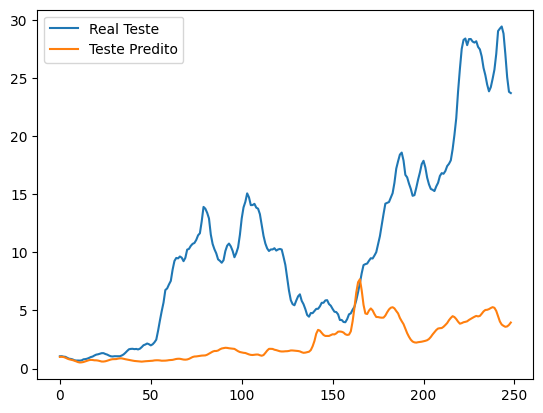

In [86]:
plt.plot(np.exp(ytest).cumprod(), label='Real Teste')
plt.plot(np.exp(pred).cumprod(), label='Teste Predito')
plt.legend()
plt.show()